# ISO18571 Quickstart

This notebook is a guided path through the three most useful example datasets: the bundled demo CSVs, one downloaded official Annex case, and one generated Annex case.

Every curve passed to `ISO18571` is an `(n, 2)` array. Column 0 is time, column 1 is signal value. The reference and comparison time columns must be finite, strictly increasing, uniformly spaced, and equal to each other.

The scorer returns raw component values, rounded ISO-style component ratings, phase-alignment metadata, and shifted curves that are helpful for visual inspection.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "tools").is_dir() and (REPO_ROOT.parent / "tools").is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

REPO_ROOT

PosixPath('/home/user/workspace/euroncap')

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from iso18571 import ISO18571, backend_info
from tools.example_data import (
    DEFAULT_GENERATED_ANNEX_DIR,
    DEFAULT_OFFICIAL_ANNEX_DIR,
    ensure_official_annex_csvs,
    first_generated_annex_curve_pair,
    first_official_annex_curve_pair,
    write_generated_annex_csvs,
)

backend_info()

{'name': 'iso18571',
 'implementation': 'C++17',
 'version': '1.0.4',
 'optimization': 'x86-64-v3'}

The setup cell resolves the repository root before importing `tools.example_data`, so the notebook works whether it is launched from the repository root or from the `examples/` directory.

The small helpers below keep the notebook focused on the workflow. `load_curve` mirrors the CSV-loading pattern in `main.py`, `plot_curve_pair` gives quick signal visibility, and `score_summary` collects the values users usually inspect first.

In [3]:
def load_curve(path: Path, delimiter: str = ",") -> np.ndarray:
    curve = np.loadtxt(path, delimiter=delimiter)
    if curve.ndim != 2 or curve.shape[1] != 2:
        raise ValueError(f"{path} must contain exactly two columns: time,value")
    return curve


def plot_curve_pair(
    reference_curve: np.ndarray, comparison_curve: np.ndarray, title: str
) -> None:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(reference_curve[:, 0], reference_curve[:, 1], label="reference")
    ax.plot(comparison_curve[:, 0], comparison_curve[:, 1], label="comparison")
    ax.set_title(title)
    ax.set_xlabel("time")
    ax.set_ylabel("value")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()


def score_summary(score: ISO18571) -> dict[str, object]:
    return {
        "rounded_scores": {
            "R": score.overall_rating(),
            "Z": score.corridor_rating(),
            "EP": score.phase_rating(),
            "EM": score.magnitude_rating(),
            "ES": score.slope_rating(),
        },
        "n_eps": score.n_eps,
        "rho_e": score.rho_e,
        "shifted_reference_shape": score.shifted_reference_curve.shape,
        "shifted_comparison_shape": score.shifted_comparison_curve.shape,
    }

## Stage 1: bundled demo CSVs

`examples/reference.csv` and `examples/comparison.csv` are no-header `time,value` files checked into the repository. This is the same pair used by the no-argument `main.py` script.

In [4]:
reference_csv = REPO_ROOT / "examples/reference.csv"
comparison_csv = REPO_ROOT / "examples/comparison.csv"

reference_curve = load_curve(reference_csv)
comparison_curve = load_curve(comparison_csv)

reference_curve.shape, comparison_curve.shape

((600, 2), (600, 2))

Before scoring, plot the two input signals. Visual inspection is useful because ISO/TS 18571 combines corridor, phase, magnitude, and slope behavior; a single overall number should not be the only thing you look at.

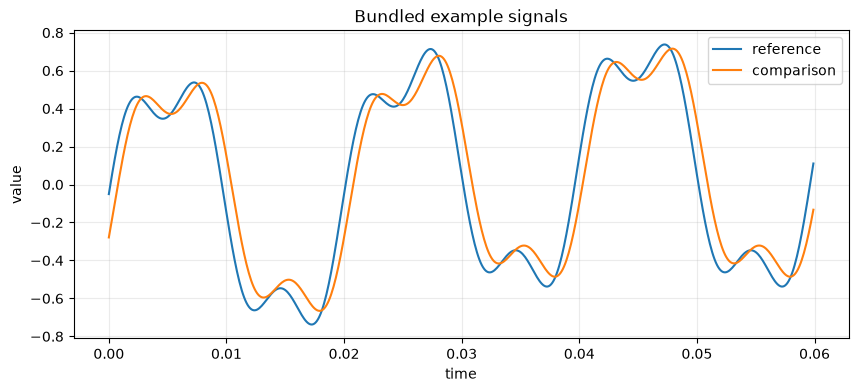

In [5]:
plot_curve_pair(reference_curve, comparison_curve, "Bundled example signals")

Now run the scorer. The `scores` dictionary contains unrounded component values and phase-alignment metadata from the native backend.

In [6]:
demo_score = ISO18571(reference_curve, comparison_curve)
demo_score.scores

{'Z': 0.6528907168993218,
 'EP': 0.9416666666666667,
 'EM': 0.9506540192911954,
 'ES': 0.9566865092308944,
 'R': 0.8309577257974801,
 'n_eps': 7,
 'rho_e': 0.9997659483531455,
 'reference_start': 0,
 'comparison_start': 7,
 'shift_length': 593}

The summary below shows rounded ratings for `R`, `Z`, `EP`, `EM`, and `ES`, plus the phase alignment values `n_eps` and `rho_e`. The shifted-curve shapes tell you how much overlapping signal remains after phase alignment.

In [7]:
score_summary(demo_score)

{'rounded_scores': {'R': 0.831,
  'Z': 0.653,
  'EP': 0.942,
  'EM': 0.951,
  'ES': 0.957},
 'n_eps': 7,
 'rho_e': 0.9997659483531455,
 'shifted_reference_shape': (593, 2),
 'shifted_comparison_shape': (593, 2)}

The shifted curves are the aligned signal sections used for magnitude and slope scoring. Plotting them helps separate phase differences from value-shape differences.

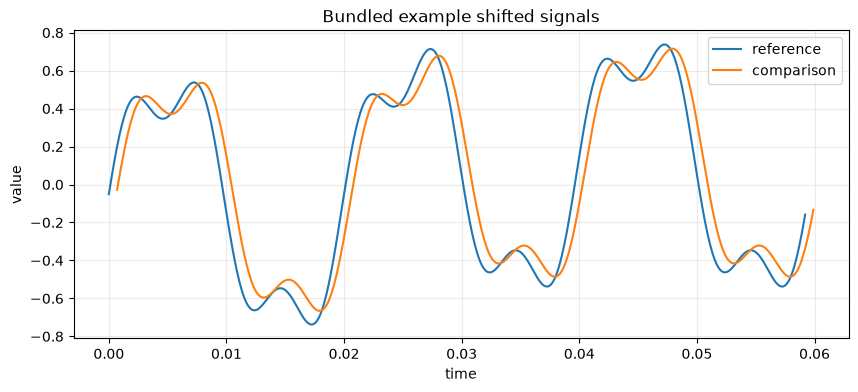

In [8]:
plot_curve_pair(
    demo_score.shifted_reference_curve,
    demo_score.shifted_comparison_curve,
    "Bundled example shifted signals",
)

The native scorer treats the time column as authoritative. This cell intentionally perturbs one comparison timestamp to show that inconsistent time grids are rejected instead of silently resampled.

In [9]:
bad_comparison = comparison_curve.copy()
bad_comparison[20, 0] += 0.5 * (comparison_curve[1, 0] - comparison_curve[0, 0])

try:
    ISO18571(reference_curve, bad_comparison)
except ValueError as exc:
    print(f"{type(exc).__name__}: {exc}")

ValueError: comparison_curve time values must have a constant interval


## Stage 2: downloaded official Annex CSVs

The official ISO/TS 18571 Annex CSV ZIP is downloaded on demand, hash-checked, and extracted under `examples/data/annex/official`. That directory is ignored by git because these files are reproducible external data.

In [10]:
official_annex_dir = ensure_official_annex_csvs(REPO_ROOT / DEFAULT_OFFICIAL_ANNEX_DIR)
official_pair = first_official_annex_curve_pair(official_annex_dir)

official_score = ISO18571(official_pair.reference_curve, official_pair.comparison_curve)
official_pair.name, score_summary(official_score)

('annex_c_1_1__ac1__cae1',
 {'rounded_scores': {'R': 0.917,
   'Z': 0.956,
   'EP': 0.952,
   'EM': 0.952,
   'ES': 0.768},
  'n_eps': 3,
  'rho_e': 0.9572915037581882,
  'shifted_reference_shape': (308, 2),
  'shifted_comparison_shape': (308, 2)})

The selected Annex case uses the official `Test` signal as reference and the official `CAE` signal as comparison. The plot makes it easy to connect the score components back to the signal behavior.

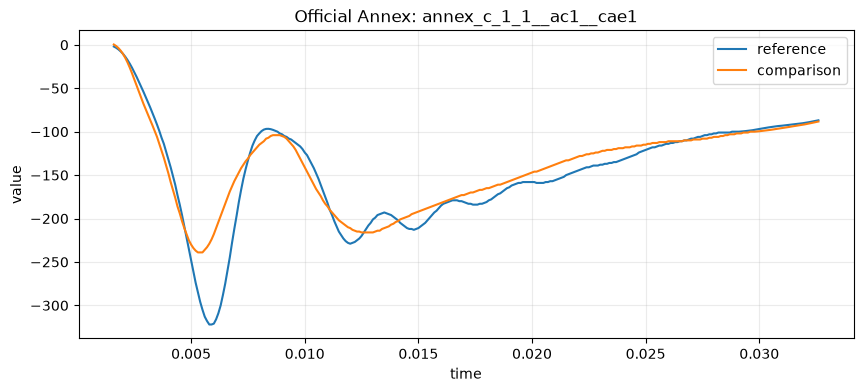

In [11]:
plot_curve_pair(
    official_pair.reference_curve,
    official_pair.comparison_curve,
    f"Official Annex: {official_pair.name}",
)

## Stage 3: generated Annex CSVs

Generated Annex CSVs are deterministic synthetic cases that are expected to score successfully and match across all parity backends. They live under `examples/data/annex/generated` when created from this notebook or from `tools/example_data.py --generate-annex`.

In [12]:
generated_annex_dir, generated_count = write_generated_annex_csvs(
    REPO_ROOT / DEFAULT_GENERATED_ANNEX_DIR
)
generated_pair = first_generated_annex_curve_pair(generated_annex_dir)

generated_score = ISO18571(
    generated_pair.reference_curve, generated_pair.comparison_curve
)
generated_count, generated_pair.name, score_summary(generated_score)

(102,
 'generated__chirp__n10',
 {'rounded_scores': {'R': 0.663,
   'Z': 0.645,
   'EP': 1.0,
   'EM': 0.492,
   'ES': 0.536},
  'n_eps': 0,
  'rho_e': 0.937667520849697,
  'shifted_reference_shape': (10, 2),
  'shifted_comparison_shape': (10, 2)})

The generated cases cover parity-safe noisy, shifted, discontinuous, and smooth signal families. This notebook shows the first one as a quick smoke path; the test suite scores the full generated set against all supported reference backends.

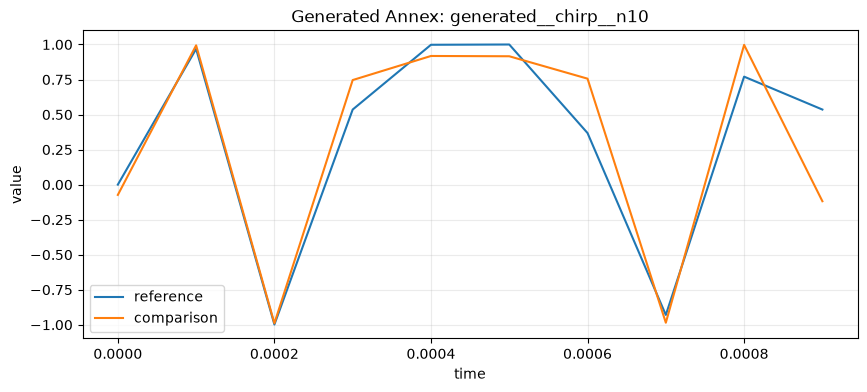

In [13]:
plot_curve_pair(
    generated_pair.reference_curve,
    generated_pair.comparison_curve,
    f"Generated Annex: {generated_pair.name}",
)